======================== FOIL : FIRST ORDER INDUCTIVE LEARNER =======================

Students : 15
Courses  : 8
Subjects : 8

Total possible Eligible(x,y) pairs : 120
Positive examples                  : 88
Negative examples                  : 32

Positive examples:
[('Alice', 'Python'), ('Alice', 'DataScience'), ('Alice', 'AI'), ('Alice', 'DatabaseSystems'), ('Alice', 'Algorithms'), ('Alice', 'MachineLearning'), ('Alice', 'Statistics'), ('Bob', 'Python'), ('Bob', 'DataScience'), ('Bob', 'AI'), ('Bob', 'Algorithms'), ('Bob', 'Statistics'), ('Charlie', 'Python'), ('Charlie', 'DataScience'), ('Charlie', 'AI'), ('Charlie', 'Algorithms'), ('Charlie', 'Statistics'), ('Diana', 'Python'), ('Diana', 'DataScience'), ('Diana', 'AI'), ('Diana', 'DatabaseSystems'), ('Diana', 'MachineLearning'), ('Diana', 'Statistics'), ('Ethan', 'Python'), ('Ethan', 'DataScience'), ('Ethan', 'AI'), ('Ethan', 'DatabaseSystems'), ('Ethan', 'Networks'), ('Ethan', 'Algorithms'), ('Ethan', 'Statistics'), ('Fiona', 'P

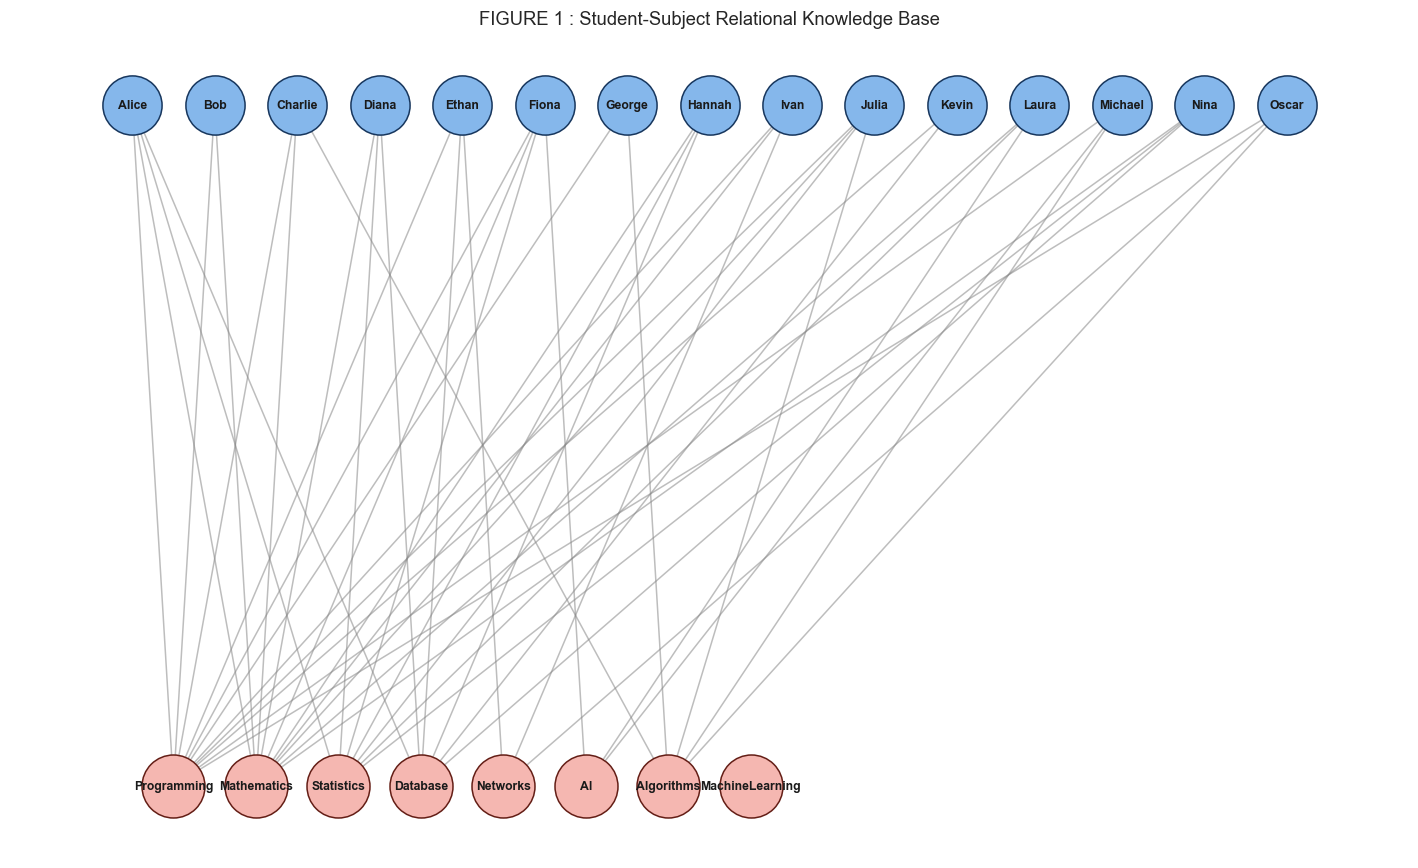

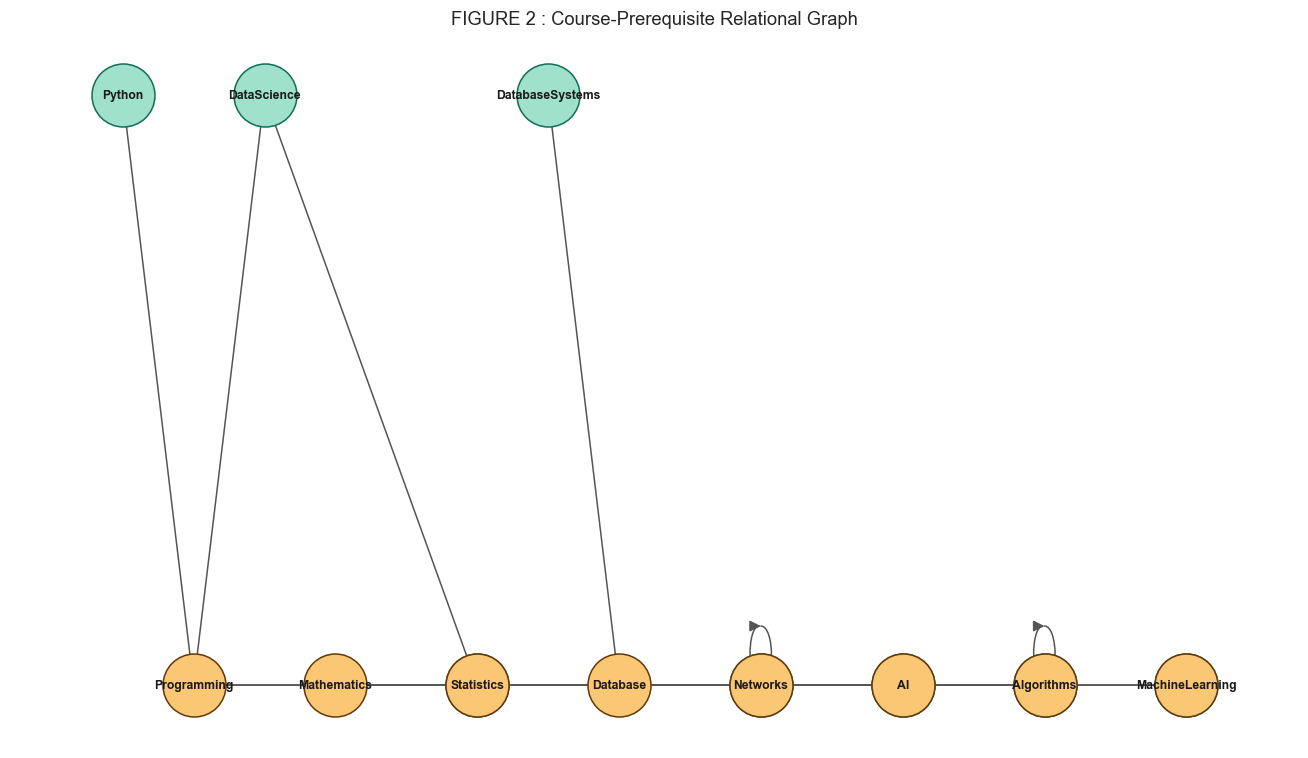

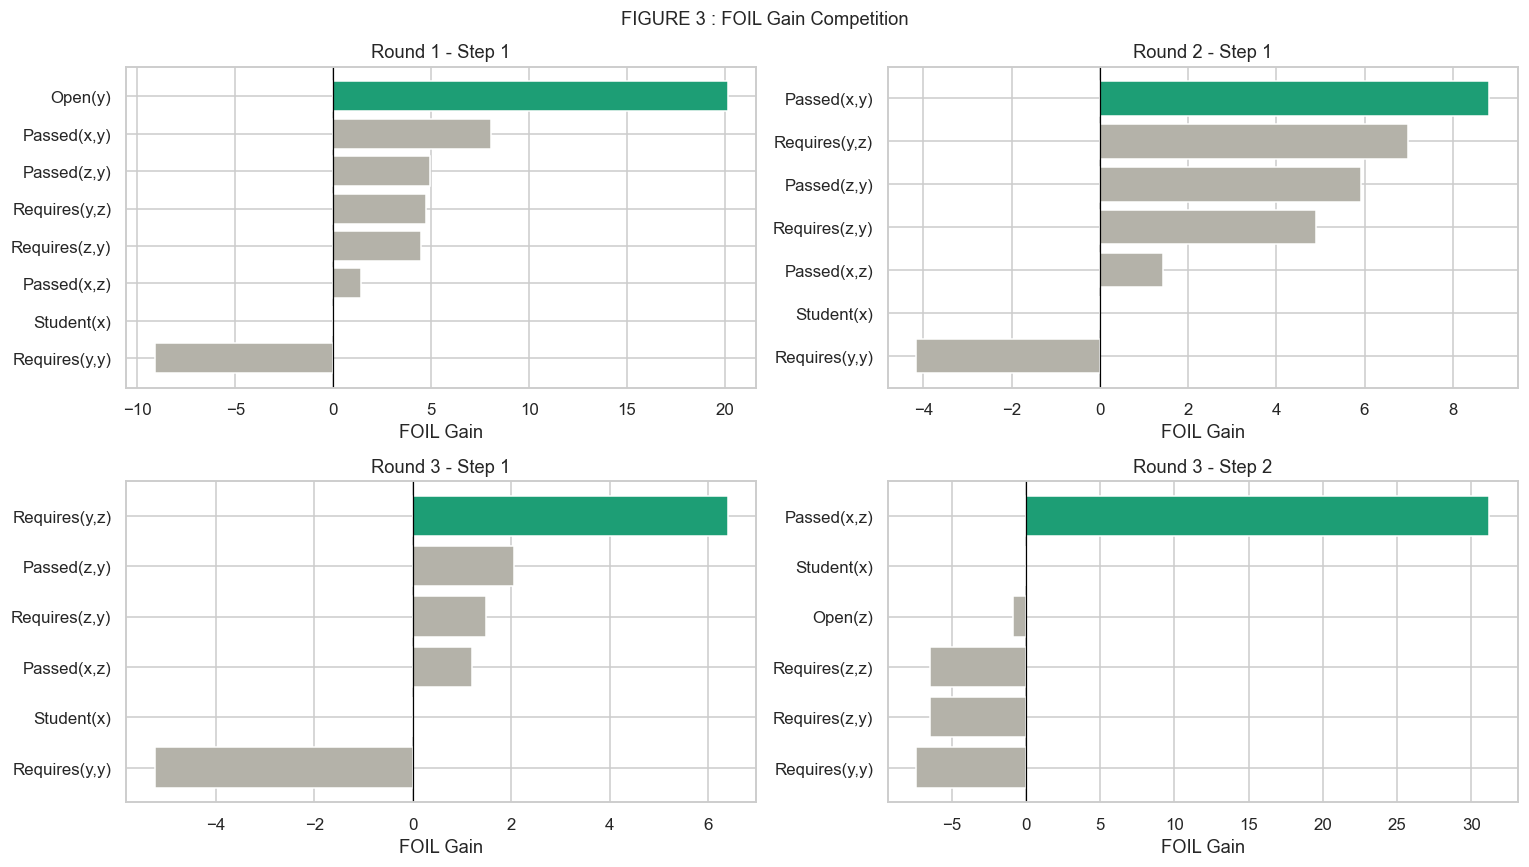

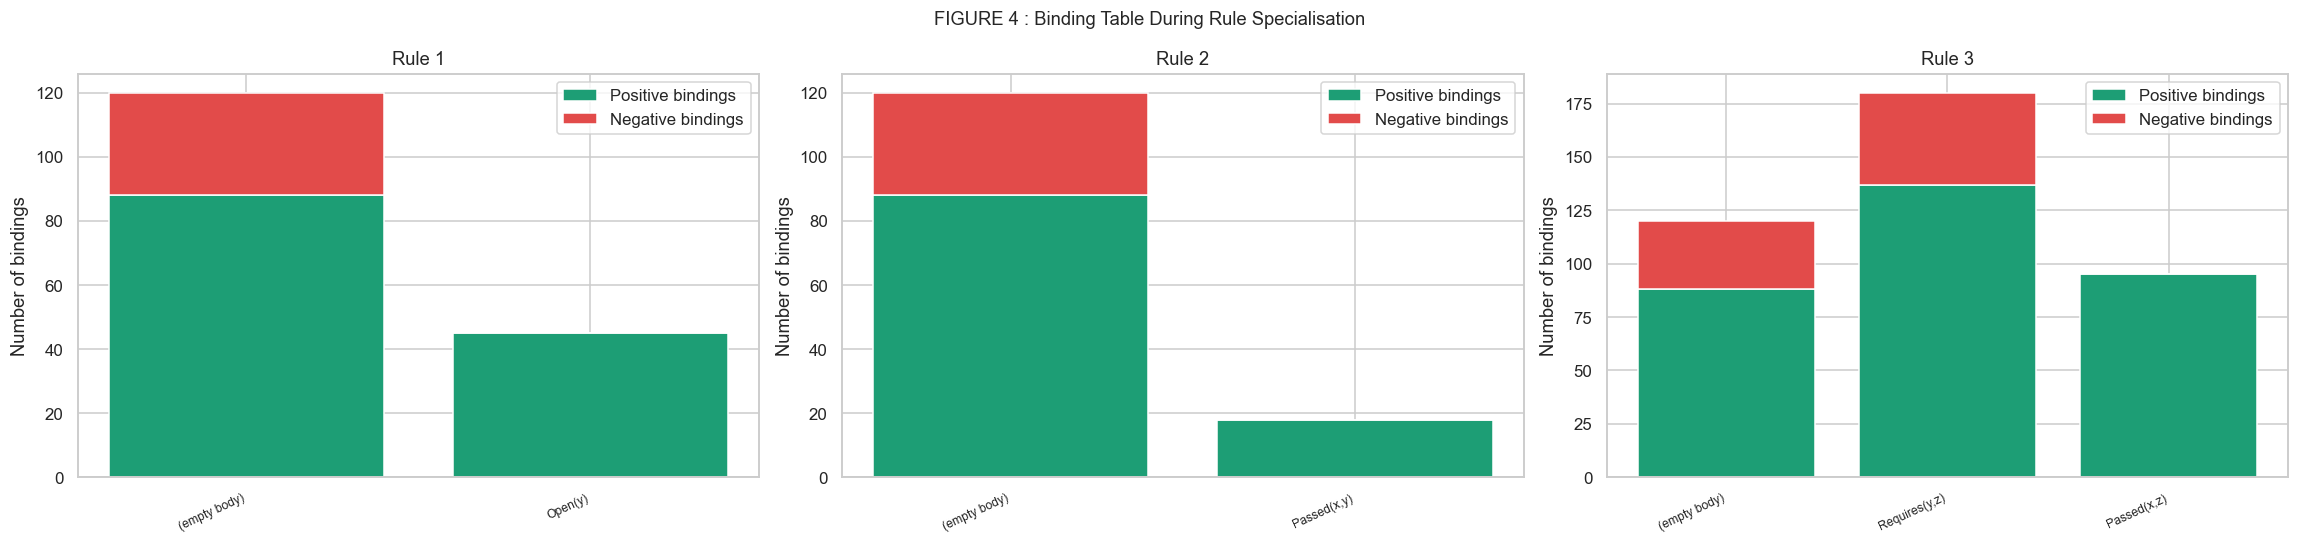

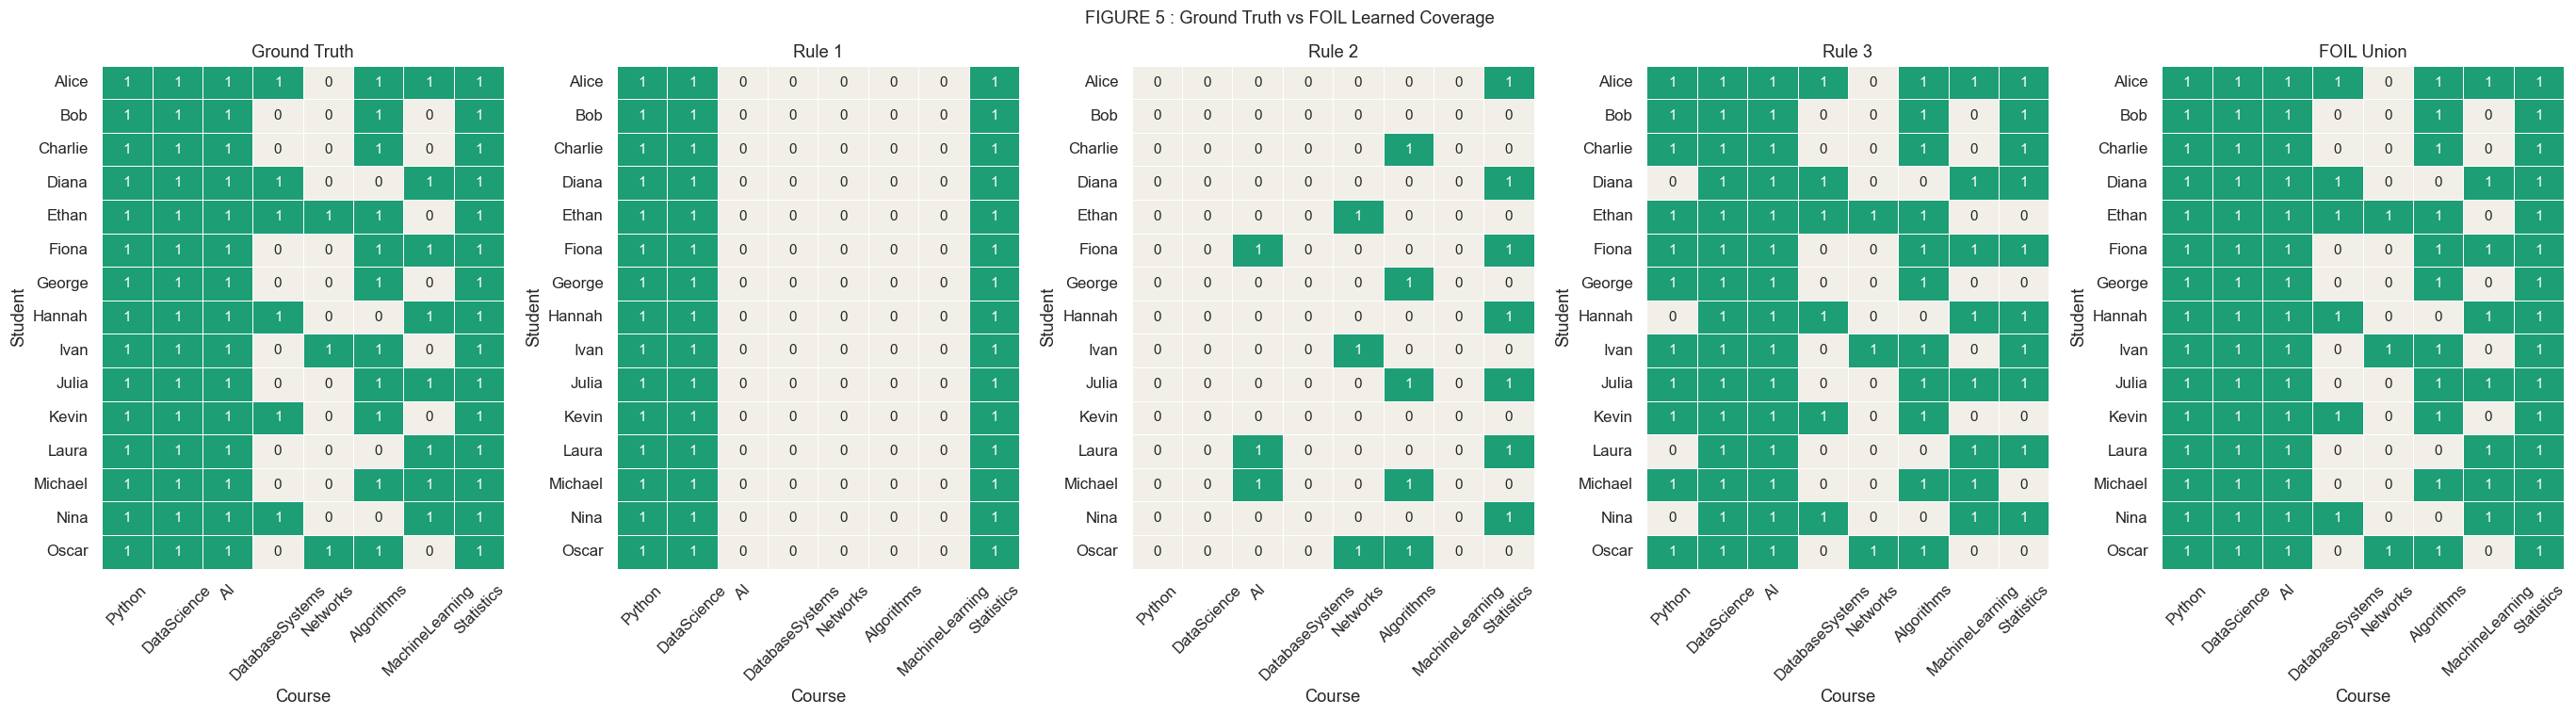


================================== CONFUSION MATRIX =================================
+-----------------+----------------------+----------------------+
|                 |   Predicted POSITIVE |   Predicted NEGATIVE |
+=================+======================+======================+
| Actual POSITIVE |                   88 |                    0 |
+-----------------+----------------------+----------------------+
| Actual NEGATIVE |                    0 |                   32 |
+-----------------+----------------------+----------------------+

Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%


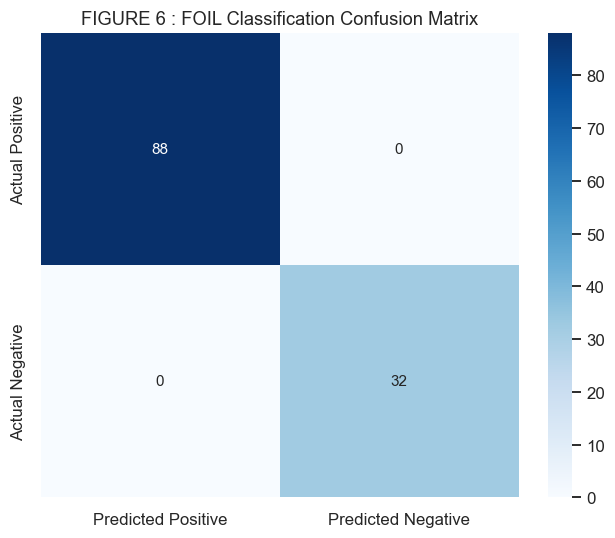


================================= RULE VERIFICATION =================================
+--------+---------------------------------------------+------------+--------------------+--------------------+
| Rule   | Learned Clause                              | Literals   |   Positive Covered |   Negative Covered |
+========+=============================================+============+====================+====================+
| R1     | Eligible(x,y) :- Open(y)                    | 1          |                 45 |                  0 |
+--------+---------------------------------------------+------------+--------------------+--------------------+
| R2     | Eligible(x,y) :- Passed(x,y)                | 1          |                 18 |                  0 |
+--------+---------------------------------------------+------------+--------------------+--------------------+
| R3     | Eligible(x,y) :- Requires(y,z), Passed(x,z) | 2          |                 79 |                  0 |
+--------+-------

In [5]:
# ============================================================================
# FOIL - FIRST ORDER INDUCTIVE LEARNER
# BCI702 : Machine Learning : Module 2 : Learning Sets of Rules
#
# DATASET:
#   Student-Course Eligibility
#
# TARGET:
#   Eligible(Student, Course)
#
# BACKGROUND PREDICATES:
#   Student(student)
#   Passed(student, subject)
#   Requires(course, subject)
#   Open(course)
#
# EXAMPLE RELATIONAL RULES:
#
#   Eligible(x,y) :- Passed(x,z), Requires(y,z)
#   Eligible(x,y) :- Open(y)
#
# This demonstrates why FOIL is useful:
#   z is a NEW variable introduced by a relational predicate.
#
# Single-cell Google Colab demonstration
# ============================================================================


# ============================================================================
# SECTION 0 : INSTALLATION AND IMPORTS
# ============================================================================

!pip install -q networkx matplotlib seaborn pandas tabulate

import math
import itertools
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10


# ============================================================================
# SECTION 1 : KNOWLEDGE BASE
# ============================================================================
#
# We now use a larger student-course dataset instead of the family dataset.
#
# Students:
#   Alice, Bob, Charlie, Diana, Ethan, Fiona, George, Hannah,
#   Ivan, Julia, Kevin, Laura, Michael, Nina, Oscar
#
# Subjects:
#   Programming, Mathematics, Statistics, Database,
#   Networks, AI, Algorithms, MachineLearning
#
# Courses:
#   Python, DataScience, AI, DatabaseSystems, Networks,
#   Algorithms, MachineLearning, Statistics
#
# The target:
#
#       Eligible(Student, Course)
#
# A student is considered eligible if:
#
#   1. The course is OPEN
#      OR
#   2. The student has passed a prerequisite required by the course.
#
# Closed World Assumption:
# Any fact not explicitly present is FALSE.
# ============================================================================


STUDENTS = [
    "Alice", "Bob", "Charlie", "Diana", "Ethan",
    "Fiona", "George", "Hannah", "Ivan", "Julia",
    "Kevin", "Laura", "Michael", "Nina", "Oscar"
]

SUBJECTS = [
    "Programming",
    "Mathematics",
    "Statistics",
    "Database",
    "Networks",
    "AI",
    "Algorithms",
    "MachineLearning"
]

COURSES = [
    "Python",
    "DataScience",
    "AI",
    "DatabaseSystems",
    "Networks",
    "Algorithms",
    "MachineLearning",
    "Statistics"
]


# ---------------------------------------------------------------------------
# BACKGROUND FACTS
# ---------------------------------------------------------------------------

FACTS = {

    # Unary predicate
    "Student": {
        (s,) for s in STUDENTS
    },

    # Passed(student, subject)
    "Passed": {

        ("Alice", "Programming"),
        ("Alice", "Mathematics"),
        ("Alice", "Statistics"),
        ("Alice", "Database"),

        ("Bob", "Programming"),
        ("Bob", "Mathematics"),

        ("Charlie", "Programming"),
        ("Charlie", "Algorithms"),
        ("Charlie", "Mathematics"),

        ("Diana", "Statistics"),
        ("Diana", "Mathematics"),
        ("Diana", "Database"),

        ("Ethan", "Programming"),
        ("Ethan", "Networks"),
        ("Ethan", "Database"),

        ("Fiona", "Programming"),
        ("Fiona", "Mathematics"),
        ("Fiona", "AI"),
        ("Fiona", "Statistics"),

        ("George", "Programming"),
        ("George", "Algorithms"),

        ("Hannah", "Mathematics"),
        ("Hannah", "Statistics"),
        ("Hannah", "Database"),

        ("Ivan", "Programming"),
        ("Ivan", "Networks"),
        ("Ivan", "Mathematics"),

        ("Julia", "Programming"),
        ("Julia", "Mathematics"),
        ("Julia", "Statistics"),
        ("Julia", "Algorithms"),

        ("Kevin", "Database"),
        ("Kevin", "Programming"),

        ("Laura", "Mathematics"),
        ("Laura", "AI"),
        ("Laura", "Statistics"),

        ("Michael", "Programming"),
        ("Michael", "Algorithms"),
        ("Michael", "AI"),

        ("Nina", "Statistics"),
        ("Nina", "Database"),
        ("Nina", "Mathematics"),

        ("Oscar", "Programming"),
        ("Oscar", "Networks"),
        ("Oscar", "Algorithms"),
    },

    # Requires(course, prerequisite)
    "Requires": {

        ("Python", "Programming"),

        ("DataScience", "Statistics"),
        ("DataScience", "Programming"),

        ("AI", "Programming"),
        ("AI", "Mathematics"),

        ("DatabaseSystems", "Database"),

        ("Networks", "Networks"),

        ("Algorithms", "Algorithms"),
        ("Algorithms", "Programming"),

        ("MachineLearning", "AI"),
        ("MachineLearning", "Statistics"),

        ("Statistics", "Mathematics"),
    },

    # Open(course)
    "Open": {

        ("Python",),
        ("DataScience",),
        ("Statistics",),
    }
}


ARITY = {
    "Student": 1,
    "Passed": 2,
    "Requires": 2,
    "Open": 1
}


TARGET = "Eligible"

TARGET_VARS = ("x", "y")


# ============================================================================
# SECTION 2 : GROUND TRUTH
# ============================================================================
#
# This function defines the concept that FOIL must learn.
#
# Eligible(x,y) is TRUE when:
#
#     Open(y)
#
# OR
#
#     there exists z such that:
#         Passed(x,z)
#         Requires(y,z)
#
# This is intentionally relational.
# ============================================================================


def is_true(pred, args):
    """Closed-world lookup."""
    return tuple(args) in FACTS[pred]


def ground_truth(student, course):

    # Rule 1:
    # Eligible(x,y) :- Open(y)
    if is_true("Open", (course,)):
        return True

    # Rule 2:
    # Eligible(x,y) :- Passed(x,z), Requires(y,z)
    for subject in SUBJECTS:

        if (
            is_true("Passed", (student, subject))
            and
            is_true("Requires", (course, subject))
        ):
            return True

    return False


# ============================================================================
# GENERATE ALL POSSIBLE STUDENT-COURSE EXAMPLES
# ============================================================================

ALL_PAIRS = [
    (student, course)
    for student in STUDENTS
    for course in COURSES
]


POSITIVES = [
    pair
    for pair in ALL_PAIRS
    if ground_truth(*pair)
]


NEGATIVES = [
    pair
    for pair in ALL_PAIRS
    if not ground_truth(*pair)
]


print("=" * 85)
print(" FOIL : FIRST ORDER INDUCTIVE LEARNER ".center(85, "="))
print("=" * 85)

print("\nStudents :", len(STUDENTS))
print("Courses  :", len(COURSES))
print("Subjects :", len(SUBJECTS))

print("\nTotal possible Eligible(x,y) pairs :", len(ALL_PAIRS))
print("Positive examples                  :", len(POSITIVES))
print("Negative examples                  :", len(NEGATIVES))

print("\nPositive examples:")
print(POSITIVES)


# ============================================================================
# SECTION 3 : DISPLAY KNOWLEDGE BASE
# ============================================================================

kb_rows = []

for predicate in ["Student", "Passed", "Requires", "Open"]:

    for fact in sorted(FACTS[predicate]):

        kb_rows.append([
            predicate,
            ", ".join(fact)
        ])


print("\nBACKGROUND KNOWLEDGE BASE")
print(
    tabulate(
        kb_rows,
        headers=["Predicate", "Arguments"],
        tablefmt="grid"
    )
)


# ============================================================================
# SECTION 4 : LITERAL REPRESENTATION
# ============================================================================
#
# A literal is:
#
#     (negated, predicate, variables)
#
# Example:
#
#     (False, "Passed", ("x","z"))
#
# represents:
#
#     Passed(x,z)
#
# ============================================================================


def lit_str(lit):

    neg, pred, variables = lit

    prefix = "not " if neg else ""

    return (
        prefix +
        pred +
        "(" +
        ",".join(variables) +
        ")"
    )


def rule_str(body):

    head = (
        TARGET +
        "(" +
        ",".join(TARGET_VARS) +
        ")"
    )

    if not body:
        return head + " :- "

    return (
        head +
        " :- " +
        ", ".join(lit_str(lit) for lit in body)
    )


# ============================================================================
# SECTION 5 : APPLY LITERAL TO BINDINGS
# ============================================================================


def extend_bindings(bindings, lit):

    """
    Apply one literal to a binding table.

    Example:

        binding = {x : Alice, y : AI}

    Literal:

        Passed(x,z)

    may create:

        {x : Alice, y : AI, z : Programming}
        {x : Alice, y : AI, z : Mathematics}
        ...

    The parent index is retained because FOIL_GAIN uses t.
    """

    neg, pred, variables = lit

    new_bindings = []
    parents = []

    for i, binding in enumerate(bindings):

        if neg:

            # Negated literals do not introduce variables.
            args = tuple(binding[v] for v in variables)

            if not is_true(pred, args):

                new_bindings.append(dict(binding))
                parents.append(i)

        else:

            for fact in FACTS[pred]:

                new_binding = dict(binding)

                valid = True

                for var, value in zip(variables, fact):

                    if var in new_binding:

                        if new_binding[var] != value:

                            valid = False
                            break

                    else:

                        new_binding[var] = value

                if valid:

                    new_bindings.append(new_binding)
                    parents.append(i)

    return new_bindings, parents


# ============================================================================
# SECTION 6 : EVALUATE RULE
# ============================================================================


def evaluate_rule(body, pairs):

    """
    Determine which (x,y) examples are covered by a rule body.
    """

    bindings = [
        {
            "x": student,
            "y": course
        }
        for student, course in pairs
    ]

    for literal in body:

        bindings, _ = extend_bindings(
            bindings,
            literal
        )

    return {
        (binding["x"], binding["y"])
        for binding in bindings
    }


# ============================================================================
# SECTION 7 : SPLIT POSITIVE / NEGATIVE BINDINGS
# ============================================================================


def split_bindings(bindings, positive_set):

    positive_indices = [
        i
        for i, binding in enumerate(bindings)
        if (binding["x"], binding["y"]) in positive_set
    ]

    negative_indices = [
        i
        for i, binding in enumerate(bindings)
        if (binding["x"], binding["y"]) not in positive_set
    ]

    return positive_indices, negative_indices


# ============================================================================
# SECTION 8 : CANDIDATE LITERAL GENERATION
# ============================================================================
#
# New variable:
#
#     z
#
# is required for relational rules such as:
#
#     Passed(x,z), Requires(y,z)
#
# ============================================================================


NEW_VAR_POOL = ["z", "w", "v"]

ENFORCE_LINKAGE = True

USE_NEGATION = False


def has_dangling_variable(body):

    counts = {}

    for _, _, variables in body:

        for variable in variables:

            counts[variable] = (
                counts.get(variable, 0) + 1
            )

    return any(
        variable not in TARGET_VARS and count < 2
        for variable, count in counts.items()
    )


def candidate_literals(body):

    used_variables = set(TARGET_VARS)

    for _, _, variables in body:

        used_variables.update(variables)

    fresh = next(
        variable
        for variable in NEW_VAR_POOL
        if variable not in used_variables
    )

    allow_new = not (
        ENFORCE_LINKAGE
        and
        has_dangling_variable(body)
    )

    variable_pool = sorted(used_variables)

    if allow_new:

        variable_pool.append(fresh)

    existing = set(used_variables)

    candidates = []

    for predicate, arity in ARITY.items():

        for combination in itertools.product(
            variable_pool,
            repeat=arity
        ):

            # The literal must connect to the existing rule.
            if not any(
                variable in existing
                for variable in combination
            ):
                continue

            # At most one new variable.
            if combination.count(fresh) > 1:
                continue

            for negated in (
                (False, True)
                if USE_NEGATION
                else (False,)
            ):

                if negated and fresh in combination:
                    continue

                literal = (
                    negated,
                    predicate,
                    combination
                )

                if literal not in body:

                    candidates.append(literal)

    return candidates


def n_new_vars(literal, body):

    used = set(TARGET_VARS)

    for _, _, variables in body:

        used.update(variables)

    return len([
        variable
        for variable in set(literal[2])
        if variable not in used
    ])


# ============================================================================
# SECTION 9 : FOIL GAIN
# ============================================================================
#
# Foil_Gain(L,R)
#
#     = t * [
#           log2(p1/(p1+n1))
#           -
#           log2(p0/(p0+n0))
#       ]
#
# ============================================================================


def foil_gain(p0, n0, p1, n1, t):

    if p1 == 0:
        return float("-inf")

    if p0 == 0:
        return float("-inf")

    if t == 0:
        return float("-inf")

    before = math.log2(
        p0 / (p0 + n0)
    )

    after = math.log2(
        p1 / (p1 + n1)
    )

    return t * (after - before)


# ============================================================================
# SECTION 10 : GLOBAL LOGS
# ============================================================================


TRACE = []

RULES = []

ROUND_LOG = []


# ============================================================================
# SECTION 11 : LEARN ONE RULE
# ============================================================================


def learn_one_rule(
    positives,
    negatives,
    round_no
):

    positive_set = set(positives)

    universe = list(positives) + list(negatives)

    body = []

    bindings = [
        {
            "x": student,
            "y": course
        }
        for student, course in universe
    ]

    positive_indices, negative_indices = (
        split_bindings(
            bindings,
            positive_set
        )
    )

    p0 = len(positive_indices)
    n0 = len(negative_indices)

    step = 0

    while n0 > 0 and step < 6:

        step += 1

        scored = []

        candidates = candidate_literals(body)

        for literal in candidates:

            new_bindings, parents = (
                extend_bindings(
                    bindings,
                    literal
                )
            )

            new_positive_indices, new_negative_indices = (
                split_bindings(
                    new_bindings,
                    positive_set
                )
            )

            p1 = len(new_positive_indices)
            n1 = len(new_negative_indices)

            surviving_parents = {
                parents[i]
                for i in new_positive_indices
            }

            t = len(
                surviving_parents &
                set(positive_indices)
            )

            gain = foil_gain(
                p0,
                n0,
                p1,
                n1,
                t
            )

            scored.append({
                "round": round_no,
                "step": step,
                "literal": lit_str(literal),
                "p1": p1,
                "n1": n1,
                "t": t,
                "gain": gain,
                "newvars": n_new_vars(
                    literal,
                    body
                )
            })

        if not scored:
            break

        # Highest gain first.
        scored.sort(
            key=lambda row: (
                -row["gain"],
                row["newvars"],
                row["literal"]
            )
        )

        TRACE.extend(scored)

        best = scored[0]

        print(
            "\n  Step %d : %s"
            % (
                step,
                rule_str(body)
            )
        )

        print(
            "  Current bindings: p=%d, n=%d"
            % (p0, n0)
        )

        valid_scores = [
            row
            for row in scored
            if row["gain"] != float("-inf")
        ]

        if valid_scores:

            top = pd.DataFrame(
                valid_scores
            )[[
                "literal",
                "p1",
                "n1",
                "t",
                "gain"
            ]].head(8)

            top["gain"] = top["gain"].round(3)

            print(
                tabulate(
                    top,
                    headers=[
                        "candidate literal",
                        "p1",
                        "n1",
                        "t",
                        "FOIL_Gain"
                    ],
                    tablefmt="simple",
                    showindex=False
                )
            )

        if best["gain"] == float("-inf"):

            print(
                "  No useful literal found."
            )

            break

        best_literal = next(
            literal
            for literal in candidates
            if lit_str(literal) == best["literal"]
        )

        print(
            "\n  --> CHOSEN : %s"
            % best["literal"]
        )

        body.append(best_literal)

        bindings, _ = extend_bindings(
            bindings,
            best_literal
        )

        positive_indices, negative_indices = (
            split_bindings(
                bindings,
                positive_set
            )
        )

        p0 = len(positive_indices)
        n0 = len(negative_indices)

    return body, p0, n0


# ============================================================================
# SECTION 12 : SEQUENTIAL COVERING / OUTER FOIL LOOP
# ============================================================================


def foil(positives, negatives):

    remaining = list(positives)

    round_no = 0

    while remaining:

        round_no += 1

        print("\n" + "=" * 85)

        print(
            " OUTER LOOP ROUND %d : %d POSITIVE EXAMPLES REMAINING "
            % (
                round_no,
                len(remaining)
            )
        )

        print("=" * 85)

        body, final_p, final_n = (
            learn_one_rule(
                remaining,
                negatives,
                round_no
            )
        )

        if not body:

            print(
                "No rule could be learned."
            )

            break

        covered = (
            evaluate_rule(
                body,
                ALL_PAIRS
            )
            &
            set(remaining)
        )

        if not covered:

            print(
                "Rule covers no new positive examples."
            )

            break

        RULES.append(body)

        ROUND_LOG.append({
            "round": round_no,
            "rule": rule_str(body),
            "literals": len(body),
            "covered": len(covered),
            "remaining_before": len(remaining),
            "final_p": final_p,
            "final_n": final_n
        })

        print(
            "\n  LEARNED RULE %d:"
            % round_no
        )

        print(
            "  %s"
            % rule_str(body)
        )

        print(
            "\n  Positive examples covered:"
        )

        print(
            sorted(covered)
        )

        remaining = [
            pair
            for pair in remaining
            if pair not in covered
        ]

    return RULES


# ============================================================================
# SECTION 13 : RUN FOIL
# ============================================================================


RULES = foil(
    POSITIVES,
    NEGATIVES
)


# ============================================================================
# SECTION 14 : PRINT FINAL RULE SET
# ============================================================================


print("\n" + "=" * 85)
print(" FINAL LEARNED RULE SET ".center(85, "="))
print("=" * 85)

for i, rule in enumerate(RULES, 1):

    print(
        "R%d : %s"
        % (
            i,
            rule_str(rule)
        )
    )


# ============================================================================
# SECTION 15 : TRACE DATAFRAME
# ============================================================================


trace_df = pd.DataFrame(TRACE)

if not trace_df.empty:

    trace_df = trace_df[
        trace_df["gain"] > float("-inf")
    ].reset_index(drop=True)


# ============================================================================
# SECTION 16 : PREDICTION FUNCTION
# ============================================================================


def predict(student, course):

    for body in RULES:

        covered = evaluate_rule(
            body,
            [(student, course)]
        )

        if (student, course) in covered:

            return True

    return False


# ============================================================================
# SECTION 17 : TEST PREDICTIONS
# ============================================================================


print("\n" + "=" * 85)
print(" SAMPLE PREDICTIONS ".center(85, "="))
print("=" * 85)


test_examples = [
    ("Alice", "Python"),
    ("Alice", "MachineLearning"),
    ("Bob", "Python"),
    ("Bob", "MachineLearning"),
    ("Diana", "DatabaseSystems"),
    ("Ethan", "Networks"),
    ("George", "AI"),
    ("Laura", "AI"),
    ("Oscar", "MachineLearning"),
]


prediction_rows = []

for student, course in test_examples:

    prediction = predict(
        student,
        course
    )

    actual = ground_truth(
        student,
        course
    )

    prediction_rows.append([
        student,
        course,
        actual,
        prediction,
        "CORRECT"
        if actual == prediction
        else "WRONG"
    ])


print(
    tabulate(
        prediction_rows,
        headers=[
            "Student",
            "Course",
            "Actual",
            "FOIL Prediction",
            "Result"
        ],
        tablefmt="grid"
    )
)


# ============================================================================
# FIGURE 1 : STUDENT -> SUBJECT GRAPH
# ============================================================================


G1 = nx.Graph()

for student in STUDENTS:

    G1.add_node(
        student,
        node_type="student"
    )

for subject in SUBJECTS:

    G1.add_node(
        subject,
        node_type="subject"
    )

for student, subject in FACTS["Passed"]:

    G1.add_edge(
        student,
        subject
    )


plt.figure(
    figsize=(13, 8)
)

student_nodes = [
    node
    for node in G1.nodes
    if node in STUDENTS
]

subject_nodes = [
    node
    for node in G1.nodes
    if node in SUBJECTS
]


layout = {}

for i, student in enumerate(STUDENTS):

    layout[student] = (
        i,
        2
    )

for i, subject in enumerate(SUBJECTS):

    layout[subject] = (
        i + 0.5,
        0
    )


nx.draw_networkx_nodes(
    G1,
    layout,
    nodelist=student_nodes,
    node_color="#85B7EB",
    node_size=1500,
    edgecolors="#17365D"
)

nx.draw_networkx_nodes(
    G1,
    layout,
    nodelist=subject_nodes,
    node_color="#F5B7B1",
    node_size=1700,
    edgecolors="#641E16"
)

nx.draw_networkx_edges(
    G1,
    layout,
    edge_color="#888888",
    alpha=0.55
)

nx.draw_networkx_labels(
    G1,
    layout,
    font_size=8,
    font_weight="bold"
)

plt.title(
    "FIGURE 1 : Student-Subject Relational Knowledge Base"
)

plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================================
# FIGURE 2 : COURSE PREREQUISITE GRAPH
# ============================================================================


G2 = nx.DiGraph()

for course in COURSES:

    G2.add_node(
        course,
        node_type="course"
    )

for subject in SUBJECTS:

    G2.add_node(
        subject,
        node_type="subject"
    )


for course, subject in FACTS["Requires"]:

    G2.add_edge(
        course,
        subject
    )


plt.figure(
    figsize=(12, 7)
)

course_nodes = COURSES

subject_nodes = SUBJECTS

pos2 = {}

for i, course in enumerate(COURSES):

    pos2[course] = (
        i,
        2
    )

for i, subject in enumerate(SUBJECTS):

    pos2[subject] = (
        i + 0.5,
        0
    )


nx.draw_networkx_nodes(
    G2,
    pos2,
    nodelist=course_nodes,
    node_color="#9FE1CB",
    node_size=1700,
    edgecolors="#0F6E56"
)

nx.draw_networkx_nodes(
    G2,
    pos2,
    nodelist=subject_nodes,
    node_color="#FAC775",
    node_size=1700,
    edgecolors="#633806"
)

nx.draw_networkx_edges(
    G2,
    pos2,
    arrows=True,
    arrowsize=15,
    edge_color="#555555"
)

nx.draw_networkx_labels(
    G2,
    pos2,
    font_size=8,
    font_weight="bold"
)

plt.title(
    "FIGURE 2 : Course-Prerequisite Relational Graph"
)

plt.axis("off")

plt.tight_layout()

plt.show()


# ============================================================================
# FIGURE 3 : FOIL GAIN COMPETITION
# ============================================================================


if not trace_df.empty:

    steps = (
        trace_df[
            ["round", "step"]
        ]
        .drop_duplicates()
        .values
        .tolist()
    )

    ncol = 2

    nrow = int(
        math.ceil(
            len(steps) / ncol
        )
    )

    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(
            14,
            4 * nrow
        )
    )

    axes = np.array(
        axes
    ).reshape(-1)

    for ax, (rnd, step) in zip(
        axes,
        steps
    ):

        subset = trace_df[
            (trace_df["round"] == rnd)
            &
            (trace_df["step"] == step)
        ]

        subset = (
            subset
            .sort_values(
                "gain",
                ascending=True
            )
            .tail(8)
        )

        maximum = subset["gain"].max()

        colors = [
            "#1D9E75"
            if gain == maximum
            else "#B4B2A9"
            for gain in subset["gain"]
        ]

        ax.barh(
            subset["literal"],
            subset["gain"],
            color=colors
        )

        ax.axvline(
            0,
            color="black",
            linewidth=0.8
        )

        ax.set_title(
            "Round %d - Step %d"
            % (
                rnd,
                step
            )
        )

        ax.set_xlabel(
            "FOIL Gain"
        )

    for ax in axes[len(steps):]:

        ax.axis("off")

    fig.suptitle(
        "FIGURE 3 : FOIL Gain Competition"
    )

    plt.tight_layout()

    plt.show()


# ============================================================================
# FIGURE 4 : BINDING TABLE SHRINKAGE
# ============================================================================


progress = []

for round_number, body in enumerate(
    RULES,
    1
):

    bindings = [
        {
            "x": student,
            "y": course
        }
        for student, course in ALL_PAIRS
    ]

    positive_set = set(POSITIVES)

    p_indices, n_indices = (
        split_bindings(
            bindings,
            positive_set
        )
    )

    progress.append({
        "round": round_number,
        "step": 0,
        "literal": "(empty body)",
        "p": len(p_indices),
        "n": len(n_indices)
    })

    for step_number, literal in enumerate(
        body,
        1
    ):

        bindings, _ = extend_bindings(
            bindings,
            literal
        )

        p_indices, n_indices = (
            split_bindings(
                bindings,
                positive_set
            )
        )

        progress.append({
            "round": round_number,
            "step": step_number,
            "literal": lit_str(literal),
            "p": len(p_indices),
            "n": len(n_indices)
        })


progress_df = pd.DataFrame(
    progress
)


if not progress_df.empty:

    rounds = sorted(
        progress_df["round"].unique()
    )

    fig, axes = plt.subplots(
        1,
        len(rounds),
        figsize=(
            7 * len(rounds),
            5
        ),
        squeeze=False
    )

    axes = axes[0]

    for ax, round_number in zip(
        axes,
        rounds
    ):

        subset = progress_df[
            progress_df["round"] == round_number
        ]

        x = np.arange(
            len(subset)
        )

        ax.bar(
            x,
            subset["p"],
            color="#1D9E75",
            label="Positive bindings"
        )

        ax.bar(
            x,
            subset["n"],
            bottom=subset["p"],
            color="#E24B4A",
            label="Negative bindings"
        )

        ax.set_xticks(x)

        ax.set_xticklabels(
            subset["literal"],
            rotation=25,
            ha="right",
            fontsize=8
        )

        ax.set_title(
            "Rule %d"
            % round_number
        )

        ax.set_ylabel(
            "Number of bindings"
        )

        ax.legend()

    fig.suptitle(
        "FIGURE 4 : Binding Table During Rule Specialisation"
    )

    plt.tight_layout()

    plt.show()


# ============================================================================
# FIGURE 5 : COVERAGE HEATMAP
# ============================================================================
#
# Rows    = students
# Columns = courses
#
# 1 = covered by the rule
# 0 = not covered
# ============================================================================


truth_matrix = np.array([
    [
        1
        if ground_truth(student, course)
        else 0
        for course in COURSES
    ]
    for student in STUDENTS
])


coverage_matrices = [
    truth_matrix
]

coverage_titles = [
    "Ground Truth"
]


union_matrix = np.zeros_like(
    truth_matrix
)


for i, body in enumerate(
    RULES,
    1
):

    covered = evaluate_rule(
        body,
        ALL_PAIRS
    )

    matrix = np.array([
        [
            1
            if (student, course) in covered
            else 0
            for course in COURSES
        ]
        for student in STUDENTS
    ])

    union_matrix = np.maximum(
        union_matrix,
        matrix
    )

    coverage_matrices.append(
        matrix
    )

    coverage_titles.append(
        "Rule %d"
        % i
    )


coverage_matrices.append(
    union_matrix
)

coverage_titles.append(
    "FOIL Union"
)


fig, axes = plt.subplots(
    1,
    len(coverage_matrices),
    figsize=(
        5 * len(coverage_matrices),
        7
    )
)


if len(coverage_matrices) == 1:

    axes = [axes]


for ax, matrix, title in zip(
    axes,
    coverage_matrices,
    coverage_titles
):

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap=[
            "#F1EFE8",
            "#1D9E75"
        ],
        cbar=False,
        linewidths=0.5,
        xticklabels=COURSES,
        yticklabels=STUDENTS,
        ax=ax
    )

    ax.set_title(
        title
    )

    ax.set_xlabel(
        "Course"
    )

    ax.set_ylabel(
        "Student"
    )

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.tick_params(
        axis="y",
        rotation=0
    )


fig.suptitle(
    "FIGURE 5 : Ground Truth vs FOIL Learned Coverage"
)

plt.tight_layout()

plt.show()


# ============================================================================
# SECTION 18 : CONFUSION MATRIX
# ============================================================================


predicted = set()

for body in RULES:

    predicted |= evaluate_rule(
        body,
        ALL_PAIRS
    )


TP = sum(
    1
    for pair in ALL_PAIRS
    if pair in predicted
    and ground_truth(*pair)
)


FP = sum(
    1
    for pair in ALL_PAIRS
    if pair in predicted
    and not ground_truth(*pair)
)


FN = sum(
    1
    for pair in ALL_PAIRS
    if pair not in predicted
    and ground_truth(*pair)
)


TN = sum(
    1
    for pair in ALL_PAIRS
    if pair not in predicted
    and not ground_truth(*pair)
)


accuracy = (
    (TP + TN)
    /
    len(ALL_PAIRS)
)


precision = (
    TP / (TP + FP)
    if TP + FP > 0
    else 0
)


recall = (
    TP / (TP + FN)
    if TP + FN > 0
    else 0
)


print("\n" + "=" * 85)
print(" CONFUSION MATRIX ".center(85, "="))
print("=" * 85)


confusion = [
    ["Actual POSITIVE", TP, FN],
    ["Actual NEGATIVE", FP, TN]
]


print(
    tabulate(
        confusion,
        headers=[
            "",
            "Predicted POSITIVE",
            "Predicted NEGATIVE"
        ],
        tablefmt="grid"
    )
)


print(
    "\nAccuracy  : %.2f%%"
    % (accuracy * 100)
)

print(
    "Precision : %.2f%%"
    % (precision * 100)
)

print(
    "Recall    : %.2f%%"
    % (recall * 100)
)


# ============================================================================
# FIGURE 6 : CONFUSION MATRIX HEATMAP
# ============================================================================


cm = np.array([
    [TP, FN],
    [FP, TN]
])


plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Predicted Positive",
        "Predicted Negative"
    ],
    yticklabels=[
        "Actual Positive",
        "Actual Negative"
    ]
)

plt.title(
    "FIGURE 6 : FOIL Classification Confusion Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================================
# SECTION 19 : RULE VERIFICATION TABLE
# ============================================================================


rule_rows = []


for i, body in enumerate(
    RULES,
    1
):

    coverage = evaluate_rule(
        body,
        ALL_PAIRS
    )

    positive_coverage = len(
        coverage &
        set(POSITIVES)
    )

    negative_coverage = len(
        coverage &
        set(NEGATIVES)
    )

    rule_rows.append([
        "R%d" % i,
        rule_str(body),
        len(body),
        positive_coverage,
        negative_coverage
    ])


rule_rows.append([
    "ALL",
    "Disjunction of learned rules",
    "-",
    TP,
    FP
])


print("\n" + "=" * 85)
print(" RULE VERIFICATION ".center(85, "="))
print("=" * 85)


print(
    tabulate(
        rule_rows,
        headers=[
            "Rule",
            "Learned Clause",
            "Literals",
            "Positive Covered",
            "Negative Covered"
        ],
        tablefmt="grid"
    )
)


# ============================================================================
# SECTION 20 : ROUND-BY-ROUND SUMMARY
# ============================================================================


print("\n" + "=" * 85)
print(" ROUND-BY-ROUND SUMMARY ".center(85, "="))
print("=" * 85)


if ROUND_LOG:

    summary_df = pd.DataFrame(
        ROUND_LOG
    )

    print(
        tabulate(
            summary_df,
            headers="keys",
            tablefmt="grid",
            showindex=False
        )
    )


# ============================================================================
# SECTION 21 : SHOW ALL POSITIVE PREDICTIONS
# ============================================================================


print("\n" + "=" * 85)
print(" FOIL POSITIVE PREDICTIONS ".center(85, "="))
print("=" * 85)


learned_positive_pairs = sorted(
    predicted
)


prediction_table = []

for student, course in learned_positive_pairs:

    prediction_table.append([
        student,
        course
    ])


print(
    tabulate(
        prediction_table,
        headers=[
            "Student",
            "Eligible Course"
        ],
        tablefmt="grid"
    )
)


# ============================================================================
# SECTION 22 : FINAL TALKING POINTS
# ============================================================================


print("\n" + "=" * 85)
print(" TALKING POINTS FOR PRESENTATION ".center(85, "="))
print("=" * 85)


print("""
1. The dataset is relational rather than a simple attribute table.

2. Student(x) is a unary predicate identifying students.

3. Passed(x,z) connects a student with a subject.

4. Requires(y,z) connects a course with a prerequisite subject.

5. The variable z is not present in the target:
       Eligible(x,y)

   FOIL can introduce z while learning a rule.

6. A learned rule may therefore look like:

       Eligible(x,y) :-
           Passed(x,z),
           Requires(y,z)

7. This is fundamentally different from ordinary propositional
   classification because the rule can express relationships
   between entities.

8. FOIL uses information gain to greedily select the next literal.

9. p and n represent positive and negative BINDINGS.

10. Adding a new variable can increase the number of bindings.

11. Sequential covering repeatedly learns one rule and removes the
    positive examples already covered.

12. The final classifier is the OR/disjunction of all learned rules.

13. The heatmap compares the actual relational concept with the
    coverage produced by the learned FOIL rules.

14. The confusion matrix verifies whether the learned rules classify
    the student-course pairs correctly.
""")


print("=" * 85)
print(" END OF FOIL DEMONSTRATION ".center(85, "="))
print("=" * 85)